<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.977 · Anàlisi de sentiments i textos</p>
    <p style="margin: 0; text-align:right;">Màster universitari de Ciència de Dades (<i>Data Science</i>)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

# Mòdul 1: Com interpretar i analitzar automàticament la informació textual

## Scripts dels mètodes explicats en el mòdul

A continuació, es presenten els scripts en Python que exemplifiquen els mètodes explicats en el mòdul.

Hi ha mètodes que requereixen unes llibreries especialitzades en processament del llenguatge natural (PLN) i en l'anàlisi de textos. La llibreria que emprarem per als mètodes de PLN serà NLTK (Natural Language Toolkit). En l'adreça següent http://www.nltk.org i en el llibre <i>Natural Language Processing with Python</i> (versió en línia: https://www.nltk.org/book/) es pot obtenir informació sobre la instal·lació d'aquesta llibreria i de com s'hi pot fer processament del llenguatge.

Paquets que es necessiten per a executar aquest notebook:
- NLTK, matplotlib, pandas, sklearn, Wordcloud, SPARQLWrapper, seaborn i lxml. Per a la instal·lació podeu usar "pip" o "conda", depenent del sistema que tingueu instal·lat.

- Recordeu que heu de mantenir la mateixa estructura de les carpetes perquè el codi trobi els fitxers .csv i les imatges que s'utilitzen.

- La llibreria que emprarem per a l'anàlisi textual serà la llibreria Gensim. Per a la seva instal·lació, consulteu https://radimrehurek.com/gensim/install.html.

<u>Nota</u>: Es recomana emprar la versió 3.6 o 3.7 de Python.

In [556]:
#Importació de les llibreries NLTK i Gensim

import nltk
import gensim

La instrucció següent que heu d'executar és "nltk.download()". En executar-la, si espereu un moment, s'obrirà una finestra emergent amb els complements de NLTK. Cal seleccionar "ALL" i instal·lar-los tots, així ho tindreu tot llest.

Si obtenim un error relacionat amb els certificats SSL, és possible que hàgim d'instal·lar els certificats per a l'ús d'SSL des de Python, mitjançant l'ordre "Install Certificates.command". Per exemple, només cal que executeu una <i>shell</i> amb:

> /Applications/Python\ 3.6/Install\ Certificates.command

In [557]:
# Si executes el notebook des de Google Colab i no executes nltk.download()
# almenys, has de descarregar els complements següents:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Els scripts següents corresponen a passos explicats en els apunts del mòdul 1.

## 1. Detecció de paraules sense preprocessament

### 1.1 Llistar paraules amb el mètode <i>split</i> ###

In [558]:
#Volem llistar les paraules d'un titular del NYT
headline = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of a drunk uncle calling everyone out at a wedding.\""

#Word_candidates és la llista de paraules resultat de fer un split del text on hi ha un espai en blanc.
#Considerem que el resultat és una llista de candidats perquè en realitat, com s'explica en el mòdul,
#no tots són realment paraules.
word_candidates = headline.split()
print(word_candidates)


['The', '"Daily', 'Show"', 'host', 'said', 'the', 'attacks', 'of', 'the', 'president', 'on', 'fellow', 'Republicans', 'at', 'a', 'meeting', 'reminded', 'him', 'of', 'a', 'drunk', 'uncle', 'calling', 'everyone', 'out', 'at', 'a', 'wedding."']


### 1.2 Comptar els candidats a paraula obtinguts amb el mètode <i>split</i> i segons la relació significant-significat

In [559]:
#Importem el mètode que crea un diccionari amb la freqüència d'aparició dels elements en una llista
from collections import Counter

#Mètode split
word_candidates = headline.split()
#Nombre de vegades que els candidats a paraula apareixen en el text
print("CÀLCUL MÈTODE SPLIT:", Counter(word_candidates), "\n")

#Relació significant-significat
#Creem una llista de candidats als quals els llevem els símbols '"' i '.' (strip).
stripped_candidates = [w.strip('".') for w in word_candidates]  #A strip('".') se le pueden añadir
#altres símbols (e. g: ?, !, :, etc.).
#Nombre de vegades que els candidats apareixen en el text després de llevar-los els signes de puntuació
print("CÀLCUL MÈTODE SIGNIFICANT-SIGNIFICAT:", Counter(stripped_candidates), "\n")

#Relació significant-significat després de convertir les paraules a minúscules
#Creem una llista de candidats sense signes de puntuació convertits a minúscules (lower()).
lower_case_stripped_candidates = [s.lower() for s in stripped_candidates]
#Nombre de vegades que els candidats sense signes de puntuació i en minúscules apareixen en el text
print("CÀLCUL DESPRÉS DE CONVERSIÓ A MINÚSCULES:", Counter(lower_case_stripped_candidates),  "\n")


CÀLCUL MÈTODE SPLIT: Counter({'a': 3, 'the': 2, 'of': 2, 'at': 2, 'The': 1, '"Daily': 1, 'Show"': 1, 'host': 1, 'said': 1, 'attacks': 1, 'president': 1, 'on': 1, 'fellow': 1, 'Republicans': 1, 'meeting': 1, 'reminded': 1, 'him': 1, 'drunk': 1, 'uncle': 1, 'calling': 1, 'everyone': 1, 'out': 1, 'wedding."': 1}) 

CÀLCUL MÈTODE SIGNIFICANT-SIGNIFICAT: Counter({'a': 3, 'the': 2, 'of': 2, 'at': 2, 'The': 1, 'Daily': 1, 'Show': 1, 'host': 1, 'said': 1, 'attacks': 1, 'president': 1, 'on': 1, 'fellow': 1, 'Republicans': 1, 'meeting': 1, 'reminded': 1, 'him': 1, 'drunk': 1, 'uncle': 1, 'calling': 1, 'everyone': 1, 'out': 1, 'wedding': 1}) 

CÀLCUL DESPRÉS DE CONVERSIÓ A MINÚSCULES: Counter({'the': 3, 'a': 3, 'of': 2, 'at': 2, 'daily': 1, 'show': 1, 'host': 1, 'said': 1, 'attacks': 1, 'president': 1, 'on': 1, 'fellow': 1, 'republicans': 1, 'meeting': 1, 'reminded': 1, 'him': 1, 'drunk': 1, 'uncle': 1, 'calling': 1, 'everyone': 1, 'out': 1, 'wedding': 1}) 



## 2. Detecció de paraules amb preprocessament del text

### 2.1 Obtenció de la llista de <i>tokens</i> amb un <i>tokenizer</i> ###

In [560]:
#Importar el mètode de la llibreria NLTK que s'ocupa d'obtenir els tokens d'un text
from nltk import word_tokenize

In [561]:
headline = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of \"a drunk uncle calling everyone out at a wedding.\""

#Tokens és la llista de tokens resultat d'aplicar el tokenizer del NLTK al text 'headline'
tokens = [w for w in word_tokenize(headline)]

print(tokens)


['The', '``', 'Daily', 'Show', "''", 'host', 'said', 'the', 'attacks', 'of', 'the', 'president', 'on', 'fellow', 'Republicans', 'at', 'a', 'meeting', 'reminded', 'him', 'of', '``', 'a', 'drunk', 'uncle', 'calling', 'everyone', 'out', 'at', 'a', 'wedding', '.', "''"]


### 2.2 Filtratge de <i>tokens</i> no alfabètics

In [562]:
#De la llista de candidats, volem llevar els candidats que no tenen caràcters alfabètics ('"', '.', etc.).
#Per a això, importem la llibreria de Python encarregada de la gestió d'expressions regulars.

import  re

In [563]:
#alpha_tokens és la llista de tokens del text que han passat el filtre. Per a obtenir la llista:
#1. es converteix el text a minúscules (headline.lower());
#2. es tokenitza el text en minúscules (word_tokenize(headline.lower()));
#3. s'afegeixen a la llista alpha_tokens els tokens que comencen per un caràcter alfabètic (re.match("^[a-z]+.*)).

alpha_tokens = [w for w in word_tokenize(headline.lower()) if re.match("^[a-z]+.*", w)]

print(alpha_tokens)

['the', 'daily', 'show', 'host', 'said', 'the', 'attacks', 'of', 'the', 'president', 'on', 'fellow', 'republicans', 'at', 'a', 'meeting', 'reminded', 'him', 'of', 'a', 'drunk', 'uncle', 'calling', 'everyone', 'out', 'at', 'a', 'wedding']


### 2.3 PoS tagging ###

In [564]:
#Per a fer l'etiquetatge de categoria gramatical d'un text, importem el tokenizer (word_tokenize) i
#el PoS tagger (pos_tag), tots dos de la llibreria NLTK.

from nltk import word_tokenize, pos_tag

In [565]:
headline = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of \"a drunk uncle calling everyone out at a wedding.\""

#El pos_tagger té com a input la llista de tokens del text i el seu output és una llista amb l'etiquetes de PoS de
#cada token. El format de l'output és una llista de tuples, on el primer element de la tupla és la forma d'un
#token i el segon element és la seva categoria gramatical. A sota es veu la relació etiqueta-categoria gramatical
#segons el Penn Treebank.

#Llista de tokens del text convertit en minúscules
tokens = [w for w in word_tokenize(headline.lower())]
#PoS tagging dels tokens de la llista
tagged_tokens = nltk.pos_tag(tokens)

print(tagged_tokens)


[('the', 'DT'), ('``', '``'), ('daily', 'JJ'), ('show', 'NN'), ("''", "''"), ('host', 'NN'), ('said', 'VBD'), ('the', 'DT'), ('attacks', 'NNS'), ('of', 'IN'), ('the', 'DT'), ('president', 'NN'), ('on', 'IN'), ('fellow', 'JJ'), ('republicans', 'NNS'), ('at', 'IN'), ('a', 'DT'), ('meeting', 'NN'), ('reminded', 'VBD'), ('him', 'PRP'), ('of', 'IN'), ('``', '``'), ('a', 'DT'), ('drunk', 'JJ'), ('uncle', 'NN'), ('calling', 'VBG'), ('everyone', 'NN'), ('out', 'RB'), ('at', 'IN'), ('a', 'DT'), ('wedding', 'NN'), ('.', '.'), ("''", "''")]


<b>Etiquetes PoS</b>

<ul>
<li>DT: Determinant</li>
<li>JJ: Adjectiu</li>
<li>NN: Nom en singular</li>
<li>NNS: Nom en plural</li>
<li>VBD: Verb en passat</li>
<li>VBG: Verb en gerundi</li>
<li>MD: Verb modal</li>
<li>IN: Preposició</li>
<li>PRP: Pronom</li>
<li>RB: Adverbi</li>
<li>CC: Conjunció coordinada</li>
<li>CD: Numeral</li>
</ul>

### 2.4 Cercador de n-gramas ###

In [566]:
#Per a fer la cerca d'n-grames d'un text, importem el tokenizer (word_tokenize) i els mètodes de cerca
#d'n-grames, tots dos de la llibreria NLTK.

from nltk import word_tokenize
from nltk.util import ngrams

In [567]:
#El cercador de n-grames té com ínput la llista de tokens del text i el seu output és una llista amb els n-grames
#d'un ordre N. Els n-grames es representen en forma de tupla.

headline = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of \"a drunk uncle calling everyone out at a wedding.\""

#Llista de tokens del text convertit en minúscules
tokens = [w for w in word_tokenize(headline.lower())]

#Llista de bigrames
print ("BIGRAMAS:", list(ngrams(tokens, 2)),"\n")

#Llista de trigrames
print ("TRIGRAMAS:", list(ngrams(tokens, 3)))


BIGRAMAS: [('the', '``'), ('``', 'daily'), ('daily', 'show'), ('show', "''"), ("''", 'host'), ('host', 'said'), ('said', 'the'), ('the', 'attacks'), ('attacks', 'of'), ('of', 'the'), ('the', 'president'), ('president', 'on'), ('on', 'fellow'), ('fellow', 'republicans'), ('republicans', 'at'), ('at', 'a'), ('a', 'meeting'), ('meeting', 'reminded'), ('reminded', 'him'), ('him', 'of'), ('of', '``'), ('``', 'a'), ('a', 'drunk'), ('drunk', 'uncle'), ('uncle', 'calling'), ('calling', 'everyone'), ('everyone', 'out'), ('out', 'at'), ('at', 'a'), ('a', 'wedding'), ('wedding', '.'), ('.', "''")] 

TRIGRAMAS: [('the', '``', 'daily'), ('``', 'daily', 'show'), ('daily', 'show', "''"), ('show', "''", 'host'), ("''", 'host', 'said'), ('host', 'said', 'the'), ('said', 'the', 'attacks'), ('the', 'attacks', 'of'), ('attacks', 'of', 'the'), ('of', 'the', 'president'), ('the', 'president', 'on'), ('president', 'on', 'fellow'), ('on', 'fellow', 'republicans'), ('fellow', 'republicans', 'at'), ('republican

Però no tots els n-grames són possibles candidats a col·locacions.

### 2.5 Cerca de n-grames que són col·locacions

In [568]:
#Per fer la cerca de n-grames que són col·locacions, importem el tokenizer (word_tokenize) i els mètodes de
#cerca de col·locacions, tots dos de la llibreria NLTK

from nltk import word_tokenize
from nltk.collocations import *

#Dels mètodes de cerca de col·locacions, carreguem les mètriques de càlcul dels bigrames i trigrames
#candidats a ser col·locacions
bigram_measures = nltk.collocations.BigramAssocMeasures()
trigram_measures = nltk.collocations.TrigramAssocMeasures()

#També importem la llibreria de Python encarregada de la gestió d'expressions regulars, per posar restriccions
#en els n-grames oposats. Per exemple, que el token inicial i el final no siguin signes de puntuació

import re

In [569]:
#La cerca de col·locacions es fa amb la funció get_collocations. Aquesta funció té dos arguments:
#1. el text en el qual es busquen les col·locacions;
#2. un nombre N dels millors candidats a ser col·locacions que volem trobar (e. g.: N=10);
#l'output és una llista dels N millors candidats a ser col·locacions que s'han trobat.

#Funcions cridades per la funció get_collocations
#get_coll_candidates: obté els bigrames i trigrames candidats a ser una col·locació.
#re_filter_candidates: de la llista de candidats es lleven aquells que tenen algun non-word element
#(per exemple, es lleva l'n-grama '" daily')
#get_n_best_candidates: obté els N millors candidats aplicant el càlcul del PMI.

def get_coll_candidates(tokens):
    bigramcandidates = BigramCollocationFinder.from_words(tokens)
    trigramcandidates = TrigramCollocationFinder.from_words(tokens)
    return bigramcandidates , trigramcandidates

def re_filter_candidates(bigram_coll_candidates, trigram_coll_candidates):
    bigram_coll_candidates.apply_word_filter(lambda w: (re.match(r'\W', w)))
    trigram_coll_candidates.apply_word_filter(lambda w: (re.match(r'\W',w)))
    return bigram_coll_candidates, trigram_coll_candidates

def get_n_best_candidates(bigram_candidates, trigram_candidates, n_best_collocations):
    nbest_bigram_candidates = bigram_candidates.nbest(bigram_measures.pmi,n_best_collocations)
    nbest_trigram_candidates = trigram_candidates.nbest(trigram_measures.pmi,n_best_collocations)
    return nbest_bigram_candidates, nbest_trigram_candidates

#La funció get_collocations fa el següent:
#1. Crea la llista de tokens del text (word_tokenize).
#2. A partir de la llista de tokens, busca els bigrames i trigrames que són candidats a ser col·locacions
#segons uns càlculs estadístics. En aquest cas, es fa el càlcul del PMI (Pointwise Mutual Information).
#3. Retorna els N millors candidats.

def get_collocations(text, n_best_collocations):
    #Creació de la llista de tokens
    tokens = word_tokenize(text)
    #A partir dels tokens obtenim els candidats a col·locacions que són bigrames i trigrames
    bigram_coll_candidates, trigram_coll_candidates = get_coll_candidates(tokens)
    #Apliquem un primer filtre d'expressions regulars als candidats
    bigram_coll_candidates_filtered, trigram_coll_candidates_filtered = re_filter_candidates(bigram_coll_candidates,
                                                                                            trigram_coll_candidates)
    #Dels bigrames i trigrames filtrats obtenim els N millors candidats amb mètodes estadístics
    best_bigrams_cand, best_trigrams_cand = get_n_best_candidates(bigram_coll_candidates_filtered,
                                                                 trigram_coll_candidates_filtered,
                                                                 n_best_collocations)
    #S'uneixen els bigrames i trigrames candidats a ser col·locacions en una llista de tuples (collocation_candidates).
    collocation_candidates = best_bigrams_cand + best_trigrams_cand
    print("NGRAMES CANDIDATS A SER COL·LOCACIONS", collocation_candidates, '\n')
    #Convertim cada tupla en un string on cada element de la tupla s'uneix amb el caracter "_".
    #Per exemple, ('new', 'york') => new_york
    collocations = ["_".join(cc) for cc in collocation_candidates]

    return collocations


In [570]:
#Exemple de cerca de col·locacions

text = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of \"a drunk uncle calling everyone out at a wedding.\""

collocations = get_collocations(text.lower(), 10) #D'un text en minúscules, obtenir els deu millors bigrames i
#trigrames candidats a ser col·locacions.

print("TERMES CANDIDATS A SER COL·LOCACIONS", collocations)


NGRAMES CANDIDATS A SER COL·LOCACIONS [('calling', 'everyone'), ('daily', 'show'), ('drunk', 'uncle'), ('everyone', 'out'), ('fellow', 'republicans'), ('host', 'said'), ('meeting', 'reminded'), ('on', 'fellow'), ('president', 'on'), ('reminded', 'him'), ('calling', 'everyone', 'out'), ('drunk', 'uncle', 'calling'), ('meeting', 'reminded', 'him'), ('on', 'fellow', 'republicans'), ('president', 'on', 'fellow'), ('uncle', 'calling', 'everyone'), ('everyone', 'out', 'at'), ('fellow', 'republicans', 'at'), ('reminded', 'him', 'of'), ('a', 'drunk', 'uncle')] 

TERMES CANDIDATS A SER COL·LOCACIONS ['calling_everyone', 'daily_show', 'drunk_uncle', 'everyone_out', 'fellow_republicans', 'host_said', 'meeting_reminded', 'on_fellow', 'president_on', 'reminded_him', 'calling_everyone_out', 'drunk_uncle_calling', 'meeting_reminded_him', 'on_fellow_republicans', 'president_on_fellow', 'uncle_calling_everyone', 'everyone_out_at', 'fellow_republicans_at', 'reminded_him_of', 'a_drunk_uncle']


### 2.6 Filtratge de candidats a col·locacions amb una llista d'<i>stop words</i> ###

In [571]:
stopwords = []

#Importem la llista que és a la llibreria NLTK. Per a obtenir la llista d'stopwords d'NLTK en diferents llengües,
#vegeu https://sangeetablog.wordpress.com/2015/07/28/download-stopwords-from-nltk-library/#
stopwords = nltk.corpus.stopwords.words('english')


In [572]:
#La funció get_collocations s'ha modificat afegint un segon filtratge als candidats a col·locacions.
#Aquest filtratge el produeix la funció filter_collocation_candidates, que al seu torn crida el mètode
#good_stw_candidate.

#La funció good_stw_candidate comprova que el candidat a col·locació no té un token inicial o final
#en la llista d'stopwords. El token inicial ocupa la primera posició de la tupla que representa la
#col·locació (e. g.: 'on' en ('on', 'fellow')). El token final ocupa, per tant, l'última posició d'aquesta tupla.

def good_stw_candidate(candidate):
    test = True
    if candidate[0] in stopwords or candidate[-1] in stopwords:
        test = False
    return test

def filter_collocation_candidates(candidates):
    #Si hem carregat una llista d'stopwords
    if len(stopwords) > 0:
         #creem una llista de candidats que passen el test d'stopwords
        col_candidates_filtered = [c for c in candidates if good_stw_candidate(c) == True]
    else:
        col_candidates_filtered = candidates
    return col_candidates_filtered

def get_collocations(text, n_best_collocations):
    #Creació de la llista de tokens
    tokens = word_tokenize(text)
    #A partir dels tokens obtenim els candidats a col·locacions que són bigrames i trigrames.
    bigram_coll_candidates, trigram_coll_candidates = get_coll_candidates(tokens)
    #Apliquem un primer filtre d'expressions regulars als candidats
    bigram_coll_candidates_filtered, trigram_coll_candidates_filtered = re_filter_candidates(bigram_coll_candidates,
                                                                                            trigram_coll_candidates)
    #Dels bigrames i trigrames filtrats obtenim els N millors candidats amb mètodes estadístics
    best_bigrams_cand, best_trigrams_cand = get_n_best_candidates(bigram_coll_candidates_filtered,
                                                                 trigram_coll_candidates_filtered,
                                                                 n_best_collocations)
    #S'uneixen els bigrames i trigrames candidats a ser col·locacions en una llista de tuples (collocation_candidates).
    collocation_candidates = best_bigrams_cand + best_trigrams_cand
    print("NGRAMES CANDIDATS A SER COL·LOCACIONS", collocation_candidates, '\n')
    #Es fa un segon filtratge als candidats a col·locació: es lleven els que tenen un
    #stopword com a token inicial o final.
    collocation_candidates_filtered = filter_collocation_candidates(collocation_candidates)
    #Convertim cada tupla en un string on cada element de la tupla s'uneix amb el caràcter "_".
    #Per exemple, ('new', 'york') => new_york.
    collocations = ["_".join(cc) for cc in collocation_candidates_filtered]

    return collocations


In [573]:
#Exemple de cerca de col·locacions amb filtratge d'stopwords

text = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of \"a drunk uncle calling everyone out at a wedding.\""

collocations = get_collocations(text.lower(),10)

print(collocations)


NGRAMES CANDIDATS A SER COL·LOCACIONS [('calling', 'everyone'), ('daily', 'show'), ('drunk', 'uncle'), ('everyone', 'out'), ('fellow', 'republicans'), ('host', 'said'), ('meeting', 'reminded'), ('on', 'fellow'), ('president', 'on'), ('reminded', 'him'), ('calling', 'everyone', 'out'), ('drunk', 'uncle', 'calling'), ('meeting', 'reminded', 'him'), ('on', 'fellow', 'republicans'), ('president', 'on', 'fellow'), ('uncle', 'calling', 'everyone'), ('everyone', 'out', 'at'), ('fellow', 'republicans', 'at'), ('reminded', 'him', 'of'), ('a', 'drunk', 'uncle')] 

['calling_everyone', 'daily_show', 'drunk_uncle', 'fellow_republicans', 'host_said', 'meeting_reminded', 'drunk_uncle_calling', 'president_on_fellow', 'uncle_calling_everyone']


### 2.7 Filtratge de candidats a col·locacions segons el PoS dels seus constituents

In [574]:
stopwords = []

#Els tokens inicial i final no poden ser etiquetats amb cap dels PoS següents:
no_pos_in = ['DT', 'IN', 'PRP', 'CC', 'CD','MD', 'VBG', 'VBD', 'RP']


In [575]:
#La funció filter_collocation_candidates s'ha modificat. Si no s'ha triat l'opció de filtrar
#amb stopwords, la funció retorna la llista de candidats a col·locació que superen el test definit
#per la funció good_PoS_candidate.

#La funció good_PoS_candidate comprova que el candidat a col·locació no té un token inicial o final
#etiquetat amb una etiqueta de la llista anterior. La funció fa el següent:
#1. Etiqueta els constituents del candidat a col·locació amb un PoS tagger.
#2. Comprova que ni l'etiqueta de PoS del token inicial ni l'etiqueta de PoS del token final són a la llista
#no_pos_in.

def good_PoS_candidate(candidate):
    test = True
    tokens = list(candidate) # Convertim la tupla del candidat en una llista de tokens;
                             # tokens = ['and', 'reason'].
    tagged_tokens = nltk.pos_tag(tokens) # PoS tagging [('calling', 'VBG'), ('everyone', 'NN')]
    if tagged_tokens[0][1] in no_pos_in or tagged_tokens[-1][1] in no_pos_in:
        test = False

    return test


def filter_collocation_candidates(candidates):
    #Si hem carregat una llista d'stopwords
    if len(stopwords) > 0:
        #Creem una llista de candidats que passen el test d'stopwords
        col_candidates_filtered = [c for c in candidates if good_stw_candidate(c) == True]
    #Si no es filtra per stopwords,
    else:
        #creem una llista de candidats que passen el test de PoS
        col_candidates_filtered = [c for c in candidates if good_PoS_candidate(c) == True]

    return col_candidates_filtered


In [576]:
#Exemple de cerca de col·locacions amb filtratge segons PoS dels constituents

text = "The \"Daily Show\" host said the attacks of the president on fellow Republicans at a meeting reminded \
him of \"a drunk uncle calling everyone out at a wedding.\""

collocations = get_collocations(text.lower(),10)

print(collocations)

NGRAMES CANDIDATS A SER COL·LOCACIONS [('calling', 'everyone'), ('daily', 'show'), ('drunk', 'uncle'), ('everyone', 'out'), ('fellow', 'republicans'), ('host', 'said'), ('meeting', 'reminded'), ('on', 'fellow'), ('president', 'on'), ('reminded', 'him'), ('calling', 'everyone', 'out'), ('drunk', 'uncle', 'calling'), ('meeting', 'reminded', 'him'), ('on', 'fellow', 'republicans'), ('president', 'on', 'fellow'), ('uncle', 'calling', 'everyone'), ('everyone', 'out', 'at'), ('fellow', 'republicans', 'at'), ('reminded', 'him', 'of'), ('a', 'drunk', 'uncle')] 

['daily_show', 'drunk_uncle', 'fellow_republicans', 'president_on_fellow', 'uncle_calling_everyone']


### 2.8 Detecció de termes que tenen el patró Nom i Nom + Nom

Exemples d'arbres sintàctics generats per un <i>parser</i>, amb un node N del qual penja un nom i un node CN del qual pengen dos noms.

![title](figs/N-TREE.png "ShowMyImage")
![title](figs/N-N-TREE.png "ShowMyImage")

In [577]:
#La cerca de termes amb el patró Nom i Nom + Nom es fa amb la funció get_n_and_cn.

#Aquesta funció té un argument:
#Les tuples dels tokens del text etiquetats amb la seva etiqueta PoS.
#Després de crear un arbre sintàctic del text, l'output és una llista de termes que pengen dels nodes N i CN que el
#parser ha trobat.

#La funció get_n_and_cn fa el següent:
#1. A partir de la llista de tokens etiquetats amb la seva etiqueta PoS, el parser crea un arbre on els nodes N i CN
#tenen uns patterns sintàctics definits prèviament.
#2. Per a cada node N i CN, es crea un terme amb les fulles que pengen d'aquest i s'afegeixen a una llista de termes.
#3. Retorna la llista de termes oposats.

#La funció get_n_and_cn crida a la funció patterns_and_parser per a definir els patterns sintàctics d'N i CN, i
#també els parsers que construiran aquests nodes a l'arbre.

def patterns_and_parser():
#Definició dels patterns sintàctics d'un node N. La fulla d'un node N és un nom en singular (NN)
#o en plural (NNS).
    n_patterns = """
              N: {<NN>|<NNS>}
              """
##Definició dels patterns sintàctics d'un node CN. Les fulles d'un node CN són dos noms en singular.
    cn_patterns = """
              CN: {<NN> <NN>}
              """
#Definició del parser que crearà els nodes N de l'arbre
    n_parser = nltk.RegexpParser(n_patterns)
#Definició del parser que crearà els nodes CN de l'arbre
    cn_parser = nltk.RegexpParser(cn_patterns)
    return n_patterns, cn_patterns, n_parser, cn_parser


def get_string_form(tuple_list):
    words = [cti[0] for cti in tuple_list]
    string_form = "_".join(words)
    return string_form


def get_n_and_cn(tagged_tokens):
    #Definició de patterns sintàctics i parser
    n_patterns, cn_patterns, n_parser, cn_parser = patterns_and_parser()
    #Creació dels arbres amb els nodes N
    n_tree = n_parser.parse(tagged_tokens)
    #Creació dels arbres amb els nodes CN
    cn_tree = cn_parser.parse(tagged_tokens)
    #Llistat de les fulles dels nodes N
    n_leaves = [s.leaves() for s in n_tree.subtrees() if s.label() == 'N'] # Llista de fulles N. Una fulla és una llista
                                                                           # de tuples (token, PoS)
                                                                           #(e. g.: [[('philosophers', 'NNS')],...]).
    #Llistat de les fulles dels nodes CN
    cn_leaves = [s.leaves() for s in cn_tree.subtrees() if s.label() == 'CN'] # Llista de fulles CN
                                                                              # (e.g: [('world', 'NN'),
                                                                              #        ('event', 'NN')],...])
    #Unió de tots dos llistats
    n_cn_tuples = n_leaves + cn_leaves
    #Conversió de les tuples que representen les fulles al terme
    n_and_cn = [get_string_form(c) for c in n_cn_tuples]#e.g: [('world', 'NN'), ('event', 'NN')] -> world_event

    return n_and_cn


In [578]:
#Exemple de detecció de constituents amb patró N i N+N

text = "The \"Daily Show\" host said the attacks of president Trump on fellow Republicans at a meeting reminded him \
        of \"a drunk uncle calling everyone out at a wedding.\""

#Tokenització del text en minúscules
tokens = [w for w in word_tokenize(text.lower())]
#PoS tagging dels tokens
tagged_tokens = nltk.pos_tag(tokens)
#Llista de termes que formen un N o un CN
n_and_cn = get_n_and_cn(tagged_tokens)

print(n_and_cn)


['show', 'host', 'attacks', 'president', 'trump', 'republicans', 'meeting', 'uncle', 'everyone', 'wedding', 'president_trump']


## 3. Detecció de termes rellevants

### 3.1 Llei de Zipf ###

El corpus utilitzat és el conjunt de titulars del <i>New York Times</i> publicats el març de 2018. El fitxer del corpus s'ha pres del kernel anomenat <i>March 2018 NYT Headline Click Bait</i> de la competició de Kaggle <i>New York Times Comments</i> (https://www.kaggle.com/aashita/nyt-comments).

In [579]:
#Preparació del corpus: titulars del NYT
#El fitxer del corpus té el format .csv. El fitxer conté els titulars i altres dades organitzades en
#forma de taula. Per això, utilitzem la llibreria Pandas per obtenir el text dels titulars.

import pandas as pd

#Transformem el contingut del fitxer en un dataframe
df= pd.read_csv("ArticlesMarch2018.csv")

#Els textos dels titulars estan a la columna 'headline'. Concatenem tots els textos en un string (headline_texts).
headline_texts = " ".join(df.headline.tolist())


In [580]:
#Importar mòduls

#1. Importar mètodes de processament de llenguatge natural

import nltk
#Importar tokenitzador del paquet NLTK
from nltk import word_tokenize
#Importar els mètodes estadístics d'NLTK, concretament la distribució de la freqüència de tokens en un text
#(FreqDist)
from nltk.probability import FreqDist

#2. Importar la llibreria de Python encarregada de la gestió d'expressions regulars

import re

#3. Importar la llibreria de Python de visualització de les dades

import matplotlib.pyplot as plt


In [581]:
#La funció build_zipf_histogram crea l'histograma de les paraules del text.
#L'argument de la funció és el text.
#L'output és la representació de l'histograma.

def build_zipf_histogram(text):
    #Obtenim la llista de tokens del text en minúscules
    tokens = [w for w in word_tokenize(text.lower())]
    #La freqüència de cada token es guarda en un diccionari que representa la distribució de la freqüència dels
    #tokens del text (frequency distribution (FreqDist)).
    freqDistribution = nltk.FreqDist(tokens)
    #La llista de tokens del diccionari s'ordenen pel seu valor de freqüència. Així, els tokens s'organitzen segons
    #el seu rang, de més freqüència a menys freqüència.
    sortedtokens = sorted(freqDistribution, key=freqDistribution.get,reverse=True)
    #Es crea una llista per a l'histograma que representa la distribució de la freqüència dels tokens
    histogram = []
    #Es crea una llista que recull la freqüència de cada token
    freqword = []
    #Elaboració de l'histograma
    for t in sortedtokens:
        #Els tokens de l'histograma han de ser de tipus paraula (es filtren els tokens que no tenen caràcters
        #alfanumèrics) i no ser un token 'unknown', que significa que no hi ha titular
        if re.match(r'\w',t) and t != 'unknown':
            #Afegim la freqüència del token a l'histograma. Ara el token ja es considera una paraula
            histogram.append(freqDistribution[t])
            #Afegim a la llista freqword un element paraula:freqüència
            freqword.append(t + ":" + str(freqDistribution[t]))
    #Imprimim la freqüència de les paraules del rang 1 al 10. Així veiem que la majoria d'aquestes paraules
    #són stopwords
    print(freqword[:10])
    return histogram

zipf_histogram = build_zipf_histogram(headline_texts)


['the:382', 'a:280', 'to:221', 'in:219', 'of:192', 's:184', 'and:165', 'for:138', 'trump:119', 'is:105']


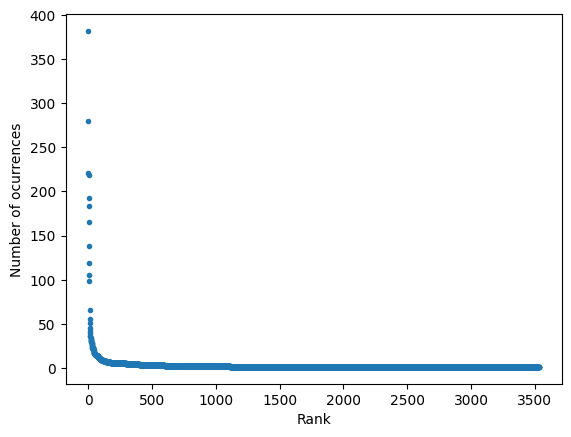

In [582]:
#La funció plot_zipf representa gràficament la relació entre la freqüència de les paraules ('Number of
#occurrences') i el seu rang ('Rank').
#La funció té com a argument l'histograma

def plot_zipf(histogram):
    plt.xlabel('Rank')
    plt.ylabel('Number of ocurrences')
    plt.plot(histogram, '.')
    plt.show()

plot_zipf(zipf_histogram)

### 3.2 Lematització i <i>stemming</i> ###

In [583]:
import nltk
#Importar els mètodes de la llibreria NLTK que lematitzen segons Wordnet
from nltk.stem.wordnet import WordNetLemmatizer
#Importar els mètodes de la llibreria NLTK que fan l'stemming segons l'algorisme Porter Stemmer
from nltk.stem import PorterStemmer

#Definim el lematitzador
lem = WordNetLemmatizer()
print("EL LEMA DE 'FEET' ÉS", lem.lemmatize('feet'))
print("EL LEMA DE 'ELEPHANTS' ÉS",lem.lemmatize('elephants'))
print("EL LEMA DE 'COMMUNITIES' ÉS",lem.lemmatize('communities'))

#Definim el stemmer
stemmer = PorterStemmer()
print("L'STEM DE 'FEET' ÉS", stemmer.stem('feet'))
print("L'STEM DE 'ELEPHANTS' ÉS", stemmer.stem('elephants'))
print("L'STEM DE 'COMMUNITIES' ÉS", stemmer.stem('communities'))


EL LEMA DE 'FEET' ÉS foot
EL LEMA DE 'ELEPHANTS' ÉS elephant
EL LEMA DE 'COMMUNITIES' ÉS community
L'STEM DE 'FEET' ÉS feet
L'STEM DE 'ELEPHANTS' ÉS eleph
L'STEM DE 'COMMUNITIES' ÉS commun


### 3.3 Termes lematitzats i unificats d'un text

Representació dels termes lematitzats i unificats dels titulars del NYT en forma de <i>word cloud</i>. La lematització es fa consultant Wordnet, que requereix del PoS de la paraula que es vol lematitzar.

In [584]:
#Importar la llibreria NLTK
import nltk
#Importar tokenitzador del paquet NLTK
from nltk import word_tokenize


In [585]:
#Importar els mètodes de la llibreria NLTK que lematitzen segons Wordnet
from nltk.stem.wordnet import WordNetLemmatizer

#Mètodes per a obtenir el lema consultant Wordnet

#Per a obtenir el lema, el terme ha de tenir una etiqueta PoS. El format de l'etiqueta PoS de Wordnet és
#diferent de l'etiqueta del pos-tagger d'NLTK.
#La funció get_wn_pos tradueix el format de PoS del terme segons el pos-tagger al format de PoS de Wordnet.
def get_wn_pos(pos):
    if re.match(r'^N',pos):
        wn_pos = 'n'
    elif re.match(r'^V',pos):
        wn_pos = 'v'
    else:
        wn_pos = 'n' #En anglès, els lemes de termes que no són verbs ni noms s'obtenen com si fossin noms
    return wn_pos

#La funció wnlemmatize lematitza el terme amb una etiqueta PoS segons el lematitzador de Wordnet
def wnlemmatize(t,postag):
    lemma = ""
    #Definició del lematitzador
    lem = WordNetLemmatizer()
    #Si el candidat és monoparaula, s'obté el lema amb el lematitzador de WordNet segons el seu PoS
    if ' ' not in t:
        lemma = lem.lemmatize(t,get_wn_pos(postag[0][1]))
    #Si el candidat és multiparaula, obtenim el seu lema com si fos un nom, aplicant el lematitzador de WordNet
    else:
        lemma = lem.lemmatize(t,'n')

    return lemma


In [586]:
#La funció unify converteix la variant sinònima d'un terme a un terme que el representa. Per exemple,
#'mr. trump' o 'donald trump' s'unifiquen en la forma 'trump'

def unify(l):
    term_unified = l
    if l == 'mr. trump' or l == 'donald trump':
        term_unified = 'trump'
    elif l == 'dpt':
        term_unified = 'department'

    return term_unified


La cerca del lema s'aplica a una paraula o a una combinació de paraules que compleixen una sèrie de condicions.

In [587]:
#Importar la llista d'stopwords en anglès de la llibreria NLTK.
stopwords = nltk.corpus.stopwords.words('english')
#Afegim stopwords
stopwords = stopwords + ['unknown', 've', 'hadn', 'll', 'didn', 'isn', 'doesn', 'hasn' ]

#no_pos_in és la llista d'etiquetes PoS que no poden tenir el token inicial i final d'un terme.
#Per exemple, un terme no pot acabar amb una preposició ('IN').
no_pos_in = ['DT', 'IN', 'PRP', 'CC', 'CD','MD', 'VBG', 'VBD', 'RP', 'RB']

#Mètode per a avaluar la idoneïtat d'una paraula o una combinació de paraules
def good_candidate(t,postag):
    v = False
    #Si és multiparaula
    if ' ' in t:
        tl = t.split(' ') #generem una llista de tokens
        #El token inicial i el token final han de ser alfabètics i no poden ser a la llista d'stopwords
        if re.match("^[a-z]+.*", tl[0]) and re.match("^[a-z]+.*", tl[-1]) and \
           tl[0] not in stopwords and tl[1] not in stopwords:
            #... ni el seu PoS pot ser a la llista no_pos_in
            if postag[0][1] not in no_pos_in and postag[-1][1] not in no_pos_in:
                v = True
    #Si és monoparaula
    else:
        #ha de ser alfabètic, i no ser a la llista d'stopwords
        if t not in stopwords and re.match("^[a-z]+.*", t):
            #i el seu PoS no pot ser a  la llista no_pos_in
            if postag[0][1] not in no_pos_in:
                v = True
    return v


Les paraules i combinacions de paraules procedeixen de l'aprenentatge d'un model de <i>phrases</i>. <i>Phrases</i> són expressions monoparaula i multiparaula que el mètode <i>good_candidate</i> validarà com a termes o no. L'aprenentatge es fa a partir d'un document. En aquest cas, serà un document que recull tots els titulars. També es poden aplicar els mètodes de cerca d'n-grames explicats a l'apartat 2.

In [588]:
#Crear el document que recull tots els titulars

import pandas as pd

#Transformem el contingut del fitxer en un dataframe
df= pd.read_csv("ArticlesMarch2018.csv")

#Els textos dels titulars són a la columna 'headline'. Cada titular es considera la unitat discursiva
#d'un document que recull tots els titulars.

#Creem el document amb tots els titulars
doc = headline_texts


In [589]:
import gensim
#De la llibreria Gensim importem els mètodes per a aprendre a detectar 'phrases'. La llibreria Gensim està
#feta per a trobar phrases que són bigrames però no trigrames. Si es volen trigrames, els phrases bigrames
#es poden convertir en un token i després tornar a repetir el procés. També es poden aplicar els mètodes
#explicats a l'apartat 2.

from gensim.models.phrases import Phraser
from gensim.models import Phrases

#El mètode Phrases necessita els paràmetres següents:
#a) Una llista (text_stream) que recull els tokens de les unitats discursives d'un document (oracions/paràgrafs).
#En el nostre cas, el text_stream és una llista els elements de la qual són els tokens de cada titular.

#b) Una freqüència mínima d'aparició (min_count).

#c) Un llindar d'idoneïtat per a considerar una combinació de paraules com un candidat a col·locació. La seva funció
#és similar a la de les mètriques com el PMI. Vegeu https://radimrehurek.com/gensim/models/phrases.html i
#Mikolov, et. al. «Distributed Representations of Words and Phrases and their Compositionality».

#d) El caràcter que unirà els components del phrase (delimiter). Per exemple, 'trade_war'.


In [590]:
#Obtenir el text_stream, que seran els tokens de cada titular

text_stream = [word_tokenize(d.lower()) for d in df.headline.tolist()]
print(text_stream[:10])


[['virtual', 'coins', ',', 'real', 'resources'], ['u.s.', 'advances', 'military', 'plans', 'for', 'north', 'korea'], ['mr.', 'trump', 'and', 'the', '‘', 'very', 'bad', 'judge', '’'], ['to', 'erase', 'dissent', ',', 'china', 'bans', 'pooh', 'bear', 'and', '‘', 'n', '’'], ['loans', 'flowed', 'to', 'kushner', 'cos.', 'after', 'visits', 'to', 'the', 'white', 'house'], ['china', 'envoy', 'intends', 'to', 'ease', 'trade', 'tensions'], ['president', 'trump', '’', 's', 'contradictory', ',', 'and', 'sometimes', 'false', ',', 'comments', 'about', 'gun', 'policy', 'to', 'lawmakers'], ['classic', 'letter', 'puzzle'], ['silicon', 'valley', 'disruption', 'in', 'an', 'australian', 'school'], ['‘', 'the', 'assassination', 'of', 'gianni', 'versace', '’', 'episode', '6', ':', 'a', 'nothing', 'man']]


In [591]:
#Entrenem el model perquè detecti phrases en els titulars

phrases = Phrases(text_stream, min_count=1, threshold=2, delimiter=' ')

#Obtenim els phrases del document que conté tots els titulars

doc_tokens = word_tokenize(doc.lower())
text_phrases = phrases[doc_tokens]

#Imprimim els primers 50 phrases
print(text_phrases[:50])


['virtual', 'coins', ',', 'real', 'resources', 'u.s.', 'advances', 'military', 'plans', 'for', 'north korea', 'mr. trump', 'and', 'the', '‘', 'very', 'bad', 'judge', '’', 'to', 'erase', 'dissent', ',', 'china', 'bans', 'pooh', 'bear', 'and', '‘', 'n', '’', 'loans', 'flowed', 'to', 'kushner', 'cos.', 'after', 'visits', 'to', 'the white', 'house', 'china', 'envoy', 'intends', 'to', 'ease', 'trade', 'tensions', 'president', 'trump ’']


Una vegada tenim els <i>phrases</i> del document, els llevem els signes de puntuació que puguin tenir adherits i ens quedem amb els que són bons candidats a termes, segons el mètode <i>good_candidate</i>. Per a comprovar si són bons candidats a terme, primer n'hem de fer l'etiquetatge PoS.

In [592]:
#Importar llibreria que processa expressions regulars
import re

#Llevem els signes de puntuació dels phrases que hi ha en els titulars

text_phrases_stripped = [tp.strip('".,;:-():!?-‘’ ') for tp in text_phrases]

#Fem etiquetatge de PoS dels phrases que hi ha en els titulars i el guardem en un diccionari (postag).

postag = {}

for tps in text_phrases_stripped:
    postag[tps] = nltk.pos_tag(word_tokenize(tps))

#Obtenim els phrases que són termes, aplicant el mètode good_candidate i tenint en compte
#el seu etiquetaje PoS.

document_terms = [tps for tps in text_phrases_stripped if good_candidate(tps,postag[tps]) == True]

#Imprimim 10 termes del document
print(document_terms[:10])


['virtual', 'coins', 'real', 'resources', 'u.s', 'advances', 'military', 'plans', 'north korea', 'mr. trump']


Lematització dels termes segons el seu etiquetatge PoS i unificació.

In [593]:
#Lematitzem els termes segons el seu etiquetaje PoS

lemmas = [wnlemmatize(tm,postag[tm]) for tm in document_terms]

#...i els unifiquem

lemmas_unified = [unify(l) for l in lemmas if l != ""]

print(lemmas_unified[:10])


['virtual', 'coin', 'real', 'resource', 'u.s', 'advance', 'military', 'plan', 'north korea', 'trump']


Creació del <i>word cloud</i>.

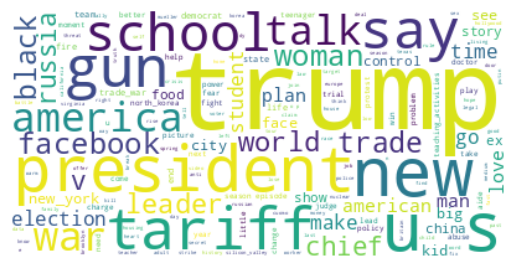

In [594]:
#Per a visualitzar els termes en un wordcloud, utilitzem la llibreria de Python wordcloud.
#Per a instal·lar-lo, s'ha d'escriure "sudo pip install wordcloud".

#Els components d'un terme multiparaula s'uneixen amb el símbol '_'

lemmas2display = " ".join([lu.replace(' ','_') for lu in lemmas_unified])

#La llibreria fa el wordcloud a partir d'un string. Per això, cal concatenar els termes
#obtinguts en un únic string (lemmas2display).

import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud_sring = " ".join(lemmas_unified)
wordcloud = WordCloud(background_color='white',max_font_size=90).generate(lemmas2display)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


## 3.4 Vectorització de documents

Exemplificarem la vectorització de documents vectoritzan els titulars del <i>New York Times</i> amb un vectoritzador TfIdf.

### 3.4.1 Exemple: vectorització de tres titulars del <i>New York Times</i> ###

In [595]:
headlines = ["Trump proclaims tariffs on steel, and a tariff on aluminium and stocks sag in reply",
"Trump embraces a trade war, which could undermine growth"]


In [596]:
#1. Importar mètodes de processament de llenguatge natural.
#Importar la llibreria NLTK.

import nltk
#Importar tokenitzador del paquet NLTK
from nltk import word_tokenize
#Importar els mètodes de la llibreria NLTK que lematitzen segons Wordnet
from nltk.stem.wordnet import WordNetLemmatizer

#2. Importar la llibreria amb els mètodes per a fer la vectorització
from sklearn.feature_extraction.text import TfidfVectorizer

In [597]:
#Definició del vectoritzador i el seu analyzer

#El mètode get_n_and_cn_lemmatized és el mètode amb el qual l'analyzer del vectoritzador troba els
#termes del text. Aquests termes tenen el pattern N i N+N.

def get_n_and_cn_lemmatized(text):
    tokens = [w for w in word_tokenize(text.lower())]
    #Etiquetatge PoS dels tokens
    tagged_tokens = nltk.pos_tag(tokens)
    #S'obtenen els termes amb el pattern N i N+N (vegeu 2.8).
    nps = get_n_and_cn(tagged_tokens)
    #Es lematitzen els termes amb el pattern N i N+N si tenen més d'un caràcter. La lematització es fa
    #segons el lematitzador de Wordnet.
    lem_nps = [wnlemmatize(np,nltk.pos_tag([np])) for np in nps if len(np) > 1]

    return lem_nps

#Definició del vectoritzador Tf.idf.
cv = TfidfVectorizer(
    analyzer= get_n_and_cn_lemmatized
 )


In [598]:
#Vectorització dels titulars
vectorizer = TfidfVectorizer()
print (headlines)
cv_fit= cv.fit_transform(headlines)
print("VECTORIZACION TITULAR 0 Y TITULAR 1",'\n',cv_fit)

#Obtenim els feature names
print ("FEATURE NAMES",'\n', cv.get_feature_names_out()) 

#Representem la vectorizació dels titulars en forma d'arrays
print("ARRAYS TITULARES 0 Y 1", '\n', cv_fit.toarray())

['Trump proclaims tariffs on steel, and a tariff on aluminium and stocks sag in reply', 'Trump embraces a trade war, which could undermine growth']
VECTORIZACION TITULAR 0 Y TITULAR 1 
   (0, 3)	0.32433627313894553
  (0, 5)	0.32433627313894553
  (0, 0)	0.32433627313894553
  (0, 4)	0.32433627313894553
  (0, 6)	0.6486725462778911
  (0, 2)	0.32433627313894553
  (0, 9)	0.23076792961123066
  (1, 8)	0.47107781233161794
  (1, 1)	0.47107781233161794
  (1, 10)	0.47107781233161794
  (1, 7)	0.47107781233161794
  (1, 9)	0.33517574332792605
FEATURE NAMES 
 ['aluminium' 'growth' 'proclaims' 'reply' 'steel' 'stock' 'tariff' 'trade'
 'trade_war' 'trump' 'war']
ARRAYS TITULARES 0 Y 1 
 [[0.32433627 0.         0.32433627 0.32433627 0.32433627 0.32433627
  0.64867255 0.         0.         0.23076793 0.        ]
 [0.         0.47107781 0.         0.         0.         0.
  0.         0.47107781 0.47107781 0.33517574 0.47107781]]


### 3.4.2 Vectorització dels titulars del NYT per la seva pertinença a un tipus de document

Creem una col·lecció de dos documents. El primer document conté els termes dels titulars de tipus TOP i el segon conté els termes dels titulars de tipus NONTOP.

In [599]:
#Preparació del corpus

#El fitxer del corpus té el format .csv. El fitxer conté els titulars i altres dades organitzades en
#forma de taula. La columna ['Tag'] indica, amb una etiqueta, si el titular és TOP o NO TOP (NONTOP).
#Per això, utilitzem la llibreria Pandas per a crear dos dataframes:
#df1: dataframe dels titulars amb l'etiqueta TOP
#df2: dataframe dels titulars amb l'etiqueta NONTOP

import pandas as pd

#Transformem el contingut del fitxer en un dataframe df
df = pd.read_csv('NYT-Comment-Headlines.csv', sep='\t')

#A partir del dataframe df creem els dataframes df1 i df2 segons el valor de 'Tag' dels titulars
df = df.set_index('Tag')
df1 = df.loc['TOP']
df2 = df.loc['NONTOP']

#Posem els titulars TOP, que són a la columna 'Headline' de df1, en una llista
top_headlines = df1['Headline'].tolist()
#Posem els titulars NO TOP, que són a la columna 'Headline' de df2, en una llista
nontop_headlines = df2['Headline'].tolist()

#Convertim els titulars TOP en un document
terms_top_doc = " ".join(top_headlines)
#Convertim els titulars NO TOP en un document
terms_nontop_doc = " ".join(nontop_headlines)

#Creem la col·lecció de documents
docs_col = [terms_top_doc, terms_nontop_doc]


Transformem cada document de la col·lecció en una llista amb els seus termes lematitzats i unificats.

In [600]:
import re

def transform_doc(doc):
    #Obtenim els phrases segons el model de detecció de phrases que ha après
    doc_phrases = phrases[word_tokenize(doc.lower())]
    #Llevem els signes de puntuació dels phrases
    text_phrases_stripped = [dp.strip('".,;:-():!?-‘’ ') for dp in doc_phrases if re.match("^[a-z]+.*", dp) ]
    #Fem etiquetatge de PoS dels phrases i el guardem en un diccionari (postag)
    postag = {}
    for tps in text_phrases_stripped:
        postag[tps] = nltk.pos_tag(word_tokenize(tps))
    #Obtenim els phrases que són termes, aplicant el mètode good_candidate i tenint en compte
    #el seu etiquetaje PoS.
    document_terms = [tps for tps in text_phrases_stripped if good_candidate(tps,postag[tps]) == True]
    #Lematitzem els termes amb el lematitzador de Wordnet
    terms_lemmatized = [wnlemmatize(dt,postag[dt]) for dt in document_terms]
    #Unifiquem els termes
    terms_lemmatized_and_unified = [unify(tl) for tl in terms_lemmatized ]
    #Concatenem els constituents d'un terme multiparaula amb '_'.
    terms_lemmatized_and_unified2display = [tlu.replace(' ','_') for tlu in terms_lemmatized_and_unified ]

    return " ".join(terms_lemmatized_and_unified2display)

transf_col = [transform_doc(d) for d in docs_col]

Vectorització dels titulars TOP i NO TOP.

In [601]:
#Importar la llibreria amb els mètodes per a fer la vectorització
from sklearn.feature_extraction.text import TfidfVectorizer

#Definim el vectoritzador. El seu analyzer busca termes de tipus 'word'. Aquest tipus inclou els termes monoparaula
#i els termes multiparaula amb un format com 'trade_war'.

hv = TfidfVectorizer(
    analyzer= 'word',
    min_df = 1.0 #Proporció de documents en els quals apareix el terme (1.0 és l'opció per defecte i
                 #significa en tots els documents).
 )

hv_fit = hv.fit_transform(transf_col)


Els resultats es visualitzaran en una taula amb dues columnes. La primera columna contindrà els termes (<i>feature names</i>) d'un document ordenats de gran a petit pel seu valor de tf.idf. La segona columna contindrà el valor de Tf.idf del <i>feature name</i>.

Imaginem que volem veure els resultats dels termes dels titulars TOP. En primer lloc, convertirem la matriu de vectorització en un <i>array</i>, i triarem el primer element de l'<i>array</i> (la primera fila de la matriu), perquè els titulars TOP són els primers de la col·lecció.

In [602]:
#Prenem l'array corresponent als titulars top
ta = hv_fit.toarray()[0]

#La relació feature name-valor de tf.idf s'expressa en forma de tupla. El primer element de la tupla és el
#feature name i el segon element és el seu valor de tf.idf en el document N, en aquest cas el document 0.
#Aquestes tuples es van posant en una llista (tfidf_tuples) i després s'ordenen de més a menys valor.

tfidf_tuples = []

feature_names = hv.get_feature_names_out()

for i in range(0, len(feature_names)):
    tfidf_tuples.append((feature_names[i], ta[i]))

#S'ordenen les tuples
sorted_tuples = sorted(tfidf_tuples, key=lambda tup: tup[1], reverse=True)

labels = ['Term', 'TfIdf']

#Es crea un dataframe a partir del qual es construirà la taula
df3 = pd.DataFrame.from_records(sorted_tuples, columns=labels)

#Construcció i visualització de la taula
print ("")
print ("Valors de TfIdf dels termes en els titulars TOP")
print ("")

print (df3)



Valors de TfIdf dels termes en els titulars TOP

          Term     TfIdf
0        trump  0.837593
1    president  0.123176
2       school  0.098540
3       tariff  0.098540
4          say  0.086223
..         ...       ...
465      write  0.012318
466      wrong  0.012318
467       year  0.012318
468        yes  0.012318
469      young  0.012318

[470 rows x 2 columns]


## 3.5 Representació de les distàncies semàntiques amb Word2Vec

En primer lloc entrenarem un model Word2Vec dels titulars TOP. Per a crear el model, cada titular TOP es pren com una oració (<i>sentence</i>) que cal transformar en una llista de <i>phrases</i> lematitzats i unificats.

In [603]:
sentence_stream = df1['Headline'].tolist() # Els textos del dataframe de titulars TOP

postag = {}

def transform_sentence(sentence):
    #Obtenim els phrases segons el model de detecció de phrases que ha après
    sentence_phrases = phrases[word_tokenize(sentence.lower())]
    #Llevem els signes de puntuació dels phrases
    phrases_stripped = [st.strip('".,;:-():!?-‘’ ') for st in sentence_phrases if re.match("^[a-z]+.*", st)]
    #Fem etiquetatge de PoS dels phrases i el guardem en un diccionari (postag).
    for ps in phrases_stripped:
        postag[ps] = nltk.pos_tag(word_tokenize(ps))
    #Lematitzem els phrases amb el lematitzador de Wordnet
    phrases_lemmatized = [wnlemmatize(ps,postag[ps]) for ps in phrases_stripped]
    #Unifiquem els phrases.
    phrases_lemmatized_and_unified = [unify(pl) for pl in phrases_lemmatized ]

    return phrases_lemmatized_and_unified

transformed_sentences = [transform_sentence(ss) for ss in sentence_stream ]

print(transformed_sentences[:5])


[['trump', 'and', 'the', 'very', 'bad', 'judge'], ['loan', 'flow', 'to', 'kushner', 'co', 'after', 'visit', 'to', 'the white', 'house'], ['goodbye', 'pay-as-you-wish'], ['can', 'venezuela', 'be', 'save'], ['say', 'a', 'prayer', 'i don', 'believe', 'in']]


Crear el model Word2Vec.

In [604]:
w2vnyt = gensim.models.Word2Vec(
        transformed_sentences,
        vector_size=150, #Mida de les dimensions del vector
        window=10, #context window (10 paraules a l'esquerra i 10 paraules a la dreta)
        min_count= 3, #Freqüència mínima
        workers= 1,
        seed=1 #Valor d'inici predefinit per a conservar la coherència
)
#... i l'entrenem amb els documents transformats
w2vnyt.train(transformed_sentences, total_examples=len(transformed_sentences), epochs=10)


(5308, 25040)

In [605]:
#Del vocabulari de phrases del model Word2Vec obtenim els que són termes

phrases_vocabulary = list(w2vnyt.wv.index_to_key)

def phrase_is_term(phrase):
    test = False
    if phrase not in postag:
        pos = nltk.pos_tag(word_tokenize(phrase))
    else:
        pos = postag[phrase]
    if good_candidate(phrase,pos):
        test = True
    return test

terms_vocabulary = [pv for pv in phrases_vocabulary if phrase_is_term(pv) == True]

print(terms_vocabulary)


['trump', 'president', 'u.s', 'tariff', 'school', 'say', 'trade', 'trade war', 'get', 'facebook', 'new', 'team', 'picture', 'state', 'aide', 'war', 'america', 'gun', 'house', 'win', 'go', 'bolton', 'good', 'talk', 'lawyer', 'chief', 'target', 'end', 'face', 'democrat', 'left', 'plan', 'security', 'voter', 'sue', 'race', 'control', 'show', 'problem', 'age', 'college', 'job', 'g.o.p', 'retreat', 'next', 'fear', 'grow', 'kushner', 'mueller', 'lead', 'teacher', 'take', 'stop', 'firm', 'play', 'power', 'data', 'chaos', 'make', 'c.e.o', 'join', 'point', 'ask', 'gun control', 'sign', 'knew', 'woman', 'porn star', 'debate', 'silence', 'russia', 'fire', 'saudi', 'prison', 'deputy', 'abuse', 'charge', 'sex', 'hold', 'void', 'class', 'call', 'man']


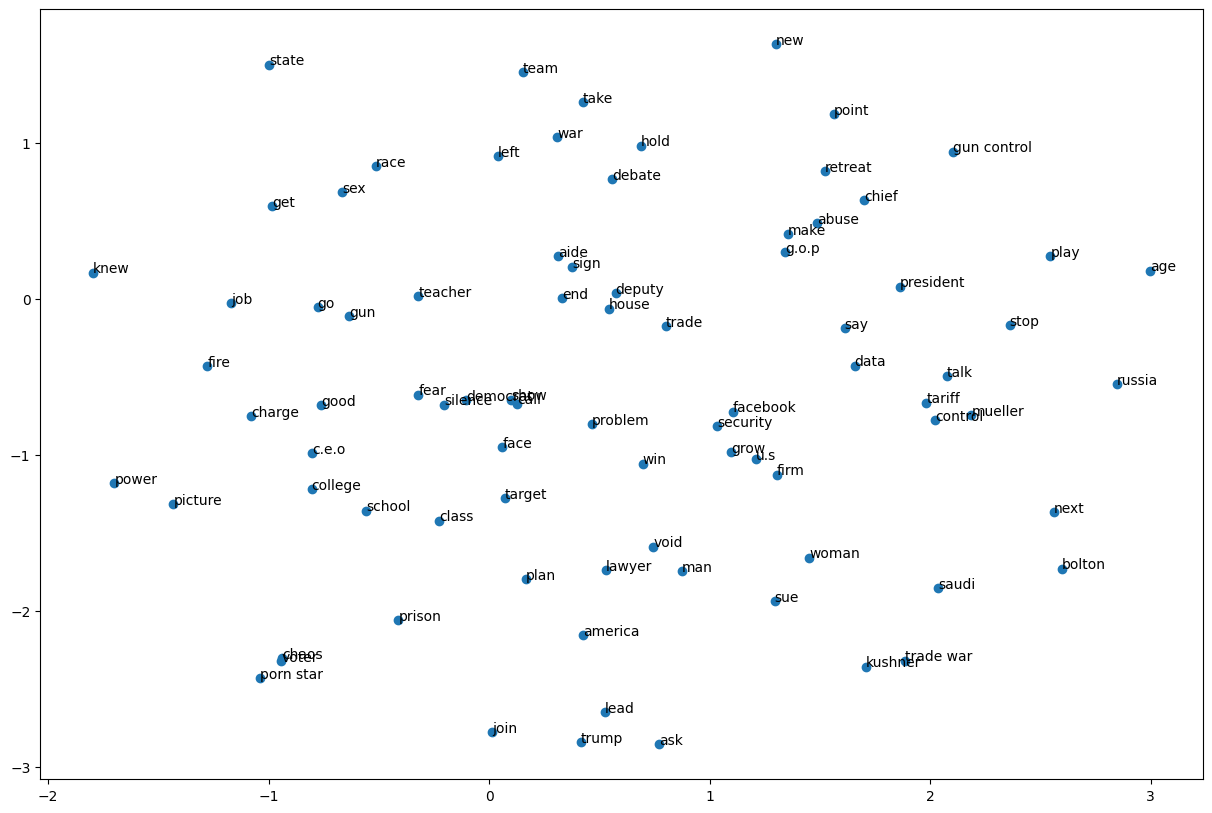

In [606]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

#Visualitzem els word embeddings mitjançant TSNE

X = w2vnyt.wv[terms_vocabulary]
tsne = TSNE(n_components=2, random_state=1)
X_tsne = tsne.fit_transform(X)
df = pd.DataFrame(X_tsne, index=terms_vocabulary, columns=['x', 'y'])
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(df['x'], df['y'])
for word, pos in df.iterrows():
    ax.annotate(word, pos)
plt.show()


Busquem les companyies de Trump (termes més propers a Trump segons Word2Vec).

In [607]:
term = 'trump'

#Considerant els termes com feature names, la relació feature name-distància s'expressa en forma de tupla.
#El primer element de la tupla és el feature name i el segon element és el seu valor de distància a un terme
#de referència (e. g.. Trump) segons #Word2Vec. Aquestes tuples es van posant en una llista (w2v_tuples) i després es
#poden ordenar de més properes a menys properes.

w2v_tuples = []

feature_names = terms_vocabulary

#Per a cada feature name, calculem la seva distància respecte al terme de referència amb el mètode model.similarity.
#Si la distància és superior a 0, la tupla es posa a la llista de tuples.
for i in range(0, len(feature_names)):
    if feature_names[i] != term and w2vnyt.wv.similarity(term, feature_names[i]) > 0:
        w2v_tuples.append((feature_names[i], w2vnyt.wv.similarity(term, feature_names[i])))

#S'ordenen les tuples
w2v_sorted_tuples = sorted(w2v_tuples, key=lambda tup: tup[1], reverse=True)

print(w2v_sorted_tuples)

labels = ['Term', 'Distance']

#Es crea un dataframe a partir del qual es construirà la taula
df4 = pd.DataFrame.from_records(w2v_sorted_tuples, columns=labels)

#Construcció i visualització de la taula
print ("")
print ("Distància respecte al terme", term)
print ("")

print (df4)


[('join', 0.37176725), ('lead', 0.35812822), ('lawyer', 0.3488531), ('facebook', 0.3409171), ('gun', 0.33998048), ('ask', 0.32693437), ('america', 0.3114568), ('end', 0.3042741), ('deputy', 0.2962962), ('charge', 0.28474557), ('democrat', 0.27302057), ('retreat', 0.2676287), ('c.e.o', 0.25919217), ('man', 0.2554764), ('race', 0.25112304), ('plan', 0.24429171), ('picture', 0.23385921), ('house', 0.23240599), ('grow', 0.22964007), ('fire', 0.22822525), ('prison', 0.22497785), ('school', 0.22377376), ('chief', 0.22346462), ('u.s', 0.21520613), ('debate', 0.21430819), ('say', 0.21303992), ('show', 0.21275638), ('sex', 0.21201667), ('kushner', 0.20882319), ('woman', 0.20801389), ('target', 0.2060909), ('voter', 0.19942388), ('team', 0.19898011), ('win', 0.19619006), ('call', 0.19320254), ('trade', 0.18499263), ('left', 0.18260837), ('college', 0.17656963), ('abuse', 0.17459473), ('sue', 0.17288387), ('firm', 0.1663371), ('security', 0.16510257), ('face', 0.15831049), ('get', 0.1519216), ('b

## 4. Detecció de temes

Primer abordarem la detecció de temes comprovant si els termes dels titulars TOP es poden agrupar per similitud semàntica segons <b>Wordnet</b>.

### 4.1 Càlcul de similitud semàntica segons Wordnet

In [608]:
#Exemples de càlcul de similitud semàntica segons Wordnet

from nltk.corpus import wordnet as wn

#Establim el synset més freqüent de les paraules 'dog', 'cat', 'united states' i 'white house'
#amb nom com el seu PoS. Seran els synsets de referència.
dog = wn.synset('dog.n.01')
cat = wn.synset('cat.n.01')
united_states = wn.synset('united_states.n.01')
spain = wn.synset('spain.n.01')

print("LA DISTÀNCIA SEMÀNTICA ENTRE 'DOG' I 'CAT' ÉS ", cat.wup_similarity(dog)) #Wu and Palmer score
print("LA DISTÀNCIA SEMÀNTICA ENTRE 'UNITED STATES' I 'SPAIN' ÉS ", united_states.wup_similarity(spain))


LA DISTÀNCIA SEMÀNTICA ENTRE 'DOG' I 'CAT' ÉS  0.8571428571428571
LA DISTÀNCIA SEMÀNTICA ENTRE 'UNITED STATES' I 'SPAIN' ÉS  0.8


In [609]:
from nltk.corpus import wordnet as wn

#Donats dos termes, volem comprovar si tenen sentits (synsets) semblants

terms = ['attack', 'fire']

#Obtenim el vocabulari de synsets dels termes

term_synsets = [wn.synsets(t,'n') for t in terms] #synsets dels dos termes quan són un nom

print("SYNSETS DELS TERMES", term_synsets)

#Posem tots els synsets dels dos termes en una sola llista

import itertools

vocabulary_synsets = list(itertools.chain.from_iterable(term_synsets))

print("VOCABULARI DE SYNSETS",vocabulary_synsets)


SYNSETS DELS TERMES [[Synset('attack.n.01'), Synset('attack.n.02'), Synset('fire.n.09'), Synset('approach.n.01'), Synset('attack.n.05'), Synset('attack.n.06'), Synset('attack.n.07'), Synset('attack.n.08'), Synset('attack.n.09')], [Synset('fire.n.01'), Synset('fire.n.02'), Synset('fire.n.03'), Synset('fire.n.04'), Synset('fire.n.05'), Synset('ardor.n.03'), Synset('fire.n.07'), Synset('fire.n.08'), Synset('fire.n.09')]]
VOCABULARI DE SYNSETS [Synset('attack.n.01'), Synset('attack.n.02'), Synset('fire.n.09'), Synset('approach.n.01'), Synset('attack.n.05'), Synset('attack.n.06'), Synset('attack.n.07'), Synset('attack.n.08'), Synset('attack.n.09'), Synset('fire.n.01'), Synset('fire.n.02'), Synset('fire.n.03'), Synset('fire.n.04'), Synset('fire.n.05'), Synset('ardor.n.03'), Synset('fire.n.07'), Synset('fire.n.08'), Synset('fire.n.09')]


In [610]:
#Per a cada synset del vocabulari crearem un vector que representa la distància semàntica d'aquest synset amb cada
#un dels synsets restants.
#El vector es construeix amb la funció create_vector que té com a argument un synset.
#La distància semàntica s'obté amb la funció get_similarity, que té com a arguments els dos synsets sobre
#els quals es calcula la distància.

def get_similarity(vs1,vs2):
    d = 0.0
    d1 = vs1.wup_similarity(vs2)  #Wu and Palmer score
    if d1 != None:
        d = d1
    return d

def create_vector(synset):
    vector = [get_similarity(synset,vs) for vs in vocabulary_synsets]
    return vector

#Obtenim els vectors de cada synset del vocabulari de synsets
synset_vectors = [create_vector(v) for v in vocabulary_synsets]

print("VECTORS DE SYNSET", synset_vectors)


VECTORS DE SYNSET [[1.0, 0.75, 0.26666666666666666, 0.6666666666666666, 0.6666666666666666, 0.5555555555555556, 0.5, 0.15384615384615385, 0.26666666666666666, 0.5714285714285714, 0.9411764705882353, 0.11764705882352941, 0.10526315789473684, 0.26666666666666666, 0.26666666666666666, 0.14285714285714285, 0.47058823529411764, 0.26666666666666666], [0.75, 1.0, 0.26666666666666666, 0.6666666666666666, 0.6666666666666666, 0.5555555555555556, 0.5, 0.15384615384615385, 0.26666666666666666, 0.5714285714285714, 0.7058823529411765, 0.11764705882352941, 0.10526315789473684, 0.26666666666666666, 0.26666666666666666, 0.14285714285714285, 0.47058823529411764, 0.26666666666666666], [0.26666666666666666, 0.26666666666666666, 1.0, 0.23529411764705882, 0.23529411764705882, 0.23529411764705882, 0.26666666666666666, 0.16666666666666666, 0.8571428571428571, 0.3076923076923077, 0.25, 0.125, 0.1111111111111111, 0.2857142857142857, 0.2857142857142857, 0.15384615384615385, 0.25, 1.0], [0.6666666666666666, 0.666

In [611]:
#Clustering amb K-means

from numpy import matrix, asarray
from sklearn.cluster import KMeans

#El conjunt de vectors de synsets es transformen en una matriu.
X = matrix(synset_vectors)
#Es defineix el nombre de clústers
num_clusters = 3

#Es defineix el model de clustering
km = KMeans(n_clusters=num_clusters, n_init=10) #nombre inicial per a mantenir la consistència

#El model s'aplica a la matriu de vectors
X = asarray(X)
km.fit(X)

labels = km.labels_.tolist()

#Resultat
print("CLÚSTERS ALS QUALS PERTANYEN ELS SYNSETS", labels)


CLÚSTERS ALS QUALS PERTANYEN ELS SYNSETS [1, 1, 0, 1, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 2, 2, 1, 0]


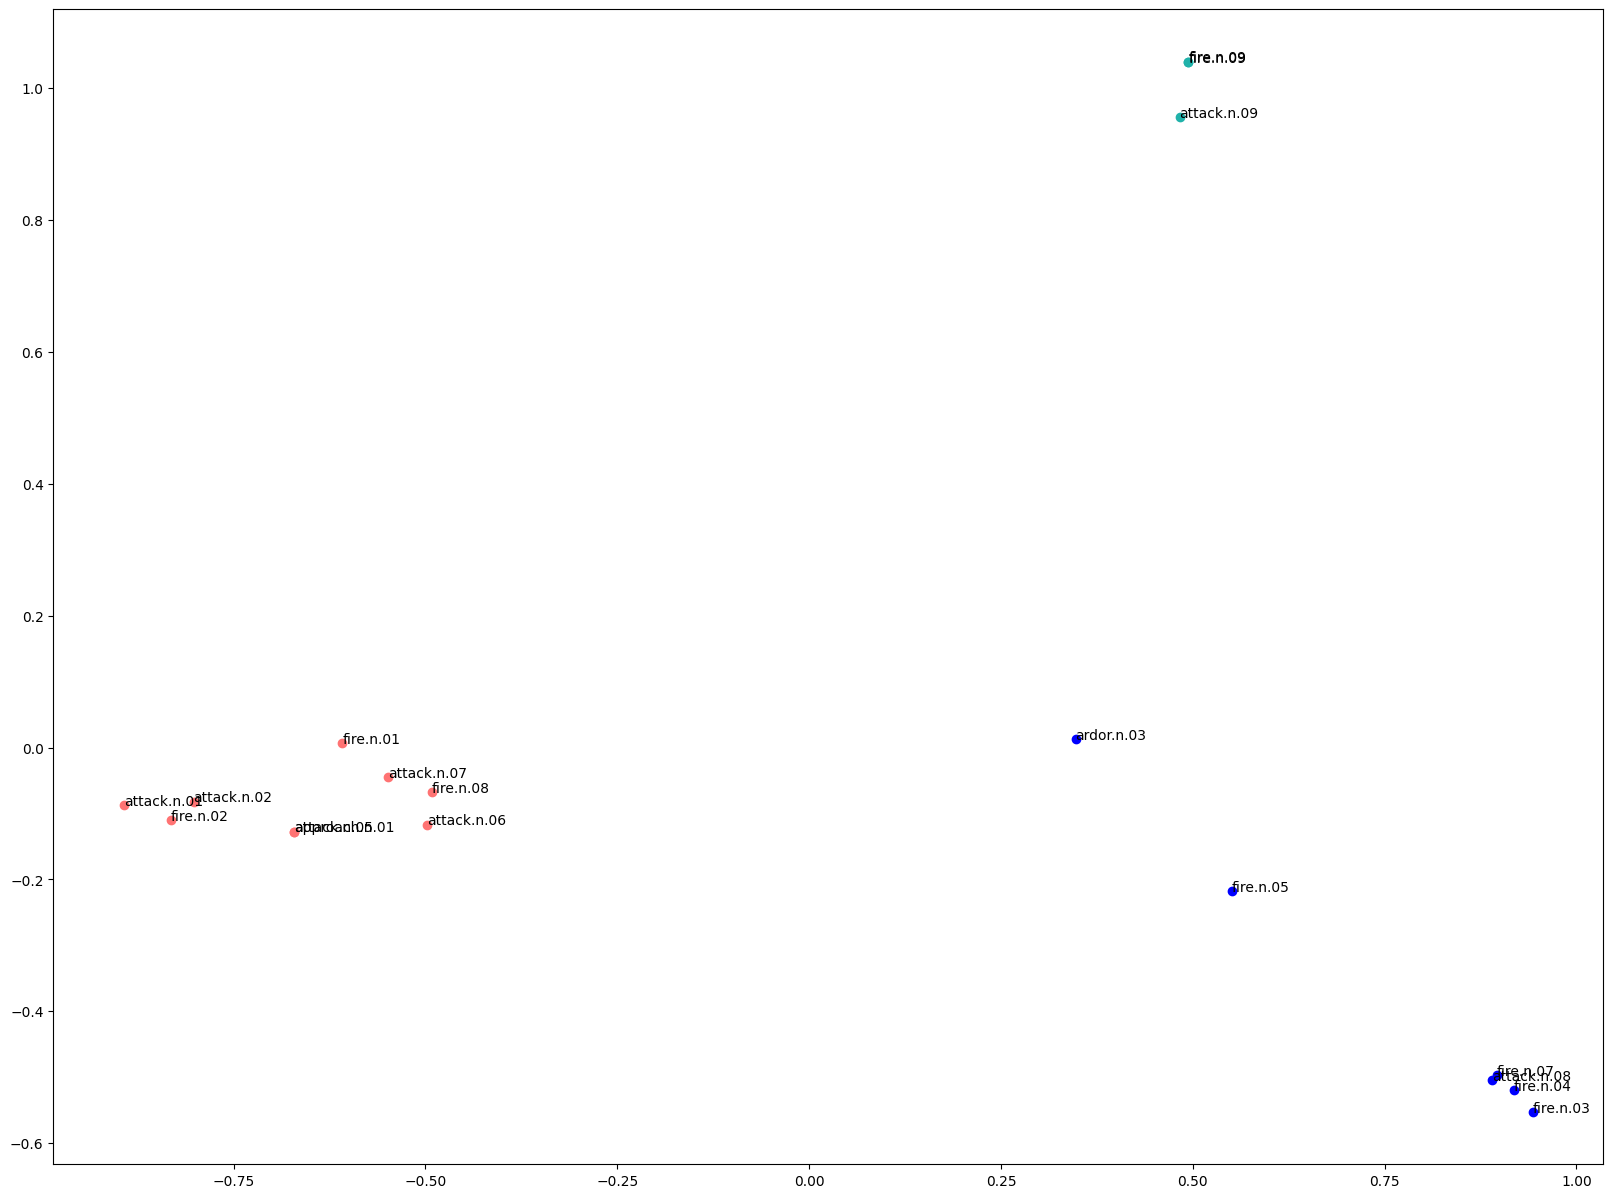

In [612]:
#Visualització

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#La reducció de dimensionalitat dels vectors es fa amb el mètode PCA

reduced_data = PCA(n_components=2).fit_transform(X)

#Representació gràfica del clustering

labels_color_map = {
    0: '#20b2aa', 1: '#ff7373' , 2: 'blue'
}

fig, ax = plt.subplots(figsize=(20,15))
for index, instance in enumerate(reduced_data):
    pca_comp_1, pca_comp_2 = reduced_data[index]
    color = labels_color_map[labels[index]]
    ax.scatter(pca_comp_1, pca_comp_2, c=color)
    ax.annotate(vocabulary_synsets[index].name(),xy=(pca_comp_1, pca_comp_2))
plt.show()


In [613]:
#Comprovem que tots dos termes tenen sentits semblants.
#Obtenim la definició (o glossa) dels synsets de Wordnet que formen un clúster

print("FIRE.n.09':", wn.synset('fire.n.09').definition())
print("ATTACK.n.09':", wn.synset('attack.n.09').definition())

FIRE.n.09': intense adverse criticism
ATTACK.n.09': strong criticism


Quan un terme no es troba a Wordnet, podem recórrer a la <b>DBpedia</b> per a trobar la seva synset.

In [614]:
!pip install pydbpedia

In [615]:
#Conèixer el synset de Wordnet consultant DBpedia

from pydbpedia import PyDBpedia, namespace

def get_dbpedia_synset(term):
    Db_query = term
    if term == 'Trump':
        Db_query = 'Donald_Trump'
    dbpedia_wrapper = PyDBpedia(endpoint="http://dbpedia.org/sparql")
    objects = dbpedia_wrapper.get_objects(subjects=["http://dbpedia.org/resource/" + Db_query], predicates=['http://dbpedia.org/property/wordnet_type'])
    return objects

synset = get_dbpedia_synset('Trump')[0]
print(synset)


http://www.w3.org/2006/03/wn/wn20/instances/synset-celebrity-noun-1


### 4.2 Càlcul de similitud semàntica segons ConceptNet

Comparació entre els resultats de similitud semàntica amb <b>Wordnet</b> i amb <b>ConceptNet</b>.

In [616]:
from nltk.corpus import wordnet as wn

united_states = wn.synset('united_states.n.01')
white_house = wn.synset('white_house.n.01')

print("LA DISTÀNCIA SEMÀNTICA ENTRE 'UNITED STATES' I 'WHITE HOUSE' SEGONS WORDNET ÉS ", \
      white_house.wup_similarity(united_states))

import requests

obj = requests.get('http://api.conceptnet.io/related/c/en/united_states?filter=/c/en/white_house').json()

print("LA DISTÀNCIA SEMÀNTICA ENTRE 'UNITED STATES' I 'WHITE HOUSE' SEGONS CONCEPTNET ÉS ", \
      obj['related'][0]['weight'])

LA DISTÀNCIA SEMÀNTICA ENTRE 'UNITED STATES' I 'WHITE HOUSE' SEGONS WORDNET ÉS  0.08695652173913043
LA DISTÀNCIA SEMÀNTICA ENTRE 'UNITED STATES' I 'WHITE HOUSE' SEGONS CONCEPTNET ÉS  0.356


### 4.3 LDA ###

Tractem ara la detecció de temes en els titulars TOP aplicant <b>LDA</b>. La distinció de temes es fa amb termes nominals. Això és, noms i termes multiparaula amb el <i>pattern</i> N+N.

In [617]:
#Vocabulari del model Word2vec

import nltk
from nltk.corpus import wordnet as wn

def isnp(t):
    v = False
    #Si el terme és una multiparaula, assumim que és un terme nominal
    if ' ' in t:
        v = True
    #Si el terme monoparaula no té synset a Wordnet, assumim que és un terme nominal que encara no s'ha
    #inclòs a Wordnet
    elif wn.synsets(t) == []:
        v = True
    else:
        try:
            #Si hi ha un synset del terme que és nominal, llavors el terme és nominal
            wn.synset(t + '.n.01')
            v = True
        except:
            pass
    return v


def get_nominals(sentence):
    #Termes nominals amb una freqüència mínima de 3 (són els termes del model Word2Vec).
    nps = [np for np in sentence if np in terms_vocabulary
           and isnp(np) == True ]
    return nps

nps_in_sentences = [get_nominals(ts) for ts in transformed_sentences if len(get_nominals(ts)) > 0]


In [618]:
#Llibreries per a fer el LDA

import gensim
import gensim.corpora as corpora

#Mètode per a fer el LDA

def lda(terms):
    dictionary = corpora.Dictionary(terms)
    #print(dictionary)
    #Creació del corpus
    texts = terms
    #Freqüència dels termes en cada document. El format és en forma de tupla
    #(índex del terme en el diccionari/vocabulari, freqüència). Per exemple, [(0, 2), (1, 1), (2, 1), (3, 1)]).
    corpus = [dictionary.doc2bow(text) for text in texts]
    #Creació del model
    ldamodel = gensim.models.ldamodel.LdaModel(corpus, # Freqüència dels termes en cada document
                                               num_topics=7, #Nombre de temes
                                               random_state=1, #Valor d'inici predefinit per a conservar coherència
                                               id2word = dictionary, #El vocabulari
                                               passes=500) #Com més passades, més consistent el model

    return ldamodel

ldamodel = lda(nps_in_sentences)


In [619]:
#Visualització del LDA

#Llibreria per a crear matrius
import numpy as np

#Llibreries per a la visualització
import pandas as pd
from IPython.display import display, HTML

#Matriu on es mostren els deu termes del vocabulari més probables de pertànyer a un topic.

K = ldamodel.num_topics
topicWordProbMat = ldamodel.print_topics(num_topics=K, num_words=10)

#La matriu es mostra com un dataframe
columns = ['1','2','3', '4', '5','6','7']
df = pd.DataFrame(columns = columns)
pd.set_option('display.width', 2000)

zz = np.zeros(shape=(1000,K))

last_number=0
DC={}

for x in range (10):
    data = pd.DataFrame({columns[0]:"",
                     columns[1]:"",
                     columns[2]:"",
                     columns[3]:"",
                     columns[4]:"",
                     columns[5]:"",
                     columns[6]:"",
                            },index=[0])
    df=df.append(data,ignore_index=True)

for line in topicWordProbMat:
    topic, word = line
    probabilities=word.split("+")
    print(probabilities)
    y=0
    for pr in probabilities:
        a=pr.split("*")
        df.iloc[y,topic] = a[1]
        if a[1] in DC:
                zz[DC[a[1]]][topic]=a[0]
        else:
            zz[last_number][topic]=a[0]
            DC[a[1]]=last_number
            last_number=last_number+1
            y=y+1

#Ordenar strings con números
def natural_keys(text):
    '''
    alist.sort(key=natural_keys) sorts in human order
    http://nedbatchelder.com/blog/200712/human_sorting.html
    (See Toothy's implementation in the comments)
    '''
    def atoi(text):
        return int(text) if text.isdigit() else text

    return [atoi(c) for c in re.split('(\d+)', text)]

df = df.reindex(columns=sorted(df.columns, key=natural_keys))
display(HTML(df.to_html()))


['0.573*"trump" ', ' 0.071*"trade" ', ' 0.041*"talk" ', ' 0.031*"chaos" ', ' 0.031*"point" ', ' 0.031*"g.o.p" ', ' 0.031*"voter" ', ' 0.021*"fear" ', ' 0.021*"job" ', ' 0.013*"show"']
['0.108*"facebook" ', ' 0.090*"state" ', ' 0.073*"college" ', ' 0.072*"sue" ', ' 0.072*"go" ', ' 0.055*"abuse" ', ' 0.055*"call" ', ' 0.055*"data" ', ' 0.055*"firm" ', ' 0.038*"stop"']
['0.112*"team" ', ' 0.093*"aide" ', ' 0.075*"bolton" ', ' 0.075*"target" ', ' 0.057*"race" ', ' 0.057*"mueller" ', ' 0.057*"saudi" ', ' 0.039*"president" ', ' 0.039*"class" ', ' 0.039*"fire"']
['0.111*"school" ', ' 0.070*"picture" ', ' 0.070*"war" ', ' 0.057*"gun" ', ' 0.057*"good" ', ' 0.057*"win" ', ' 0.057*"democrat" ', ' 0.057*"age" ', ' 0.057*"president" ', ' 0.043*"left"']
['0.112*"get" ', ' 0.112*"trade war" ', ' 0.075*"problem" ', ' 0.075*"control" ', ' 0.057*"face" ', ' 0.057*"house" ', ' 0.057*"c.e.o" ', ' 0.057*"charge" ', ' 0.039*"president" ', ' 0.039*"job"']
['0.154*"u.s" ', ' 0.099*"america" ', ' 0.080*"lawye

<ipython-input-619-e532da31ca9b>:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df=df.append(data,ignore_index=True)
<ipython-input-619-e532da31ca9b>:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df=df.append(data,ignore_index=True)
<ipython-input-619-e532da31ca9b>:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df=df.append(data,ignore_index=True)
<ipython-input-619-e532da31ca9b>:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df=df.append(data,ignore_index=True)
<ipython-input-619-e532da31ca9b>:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat ins

,1,2,3,4,5,6,7
0,"""trump""","""facebook""","""team""","""school""","""get""","""u.s""","""tariff"""
1,"""trade""","""state""","""aide""","""picture""","""trade war""","""america""","""say"""
2,"""talk""","""college""","""bolton""","""war""","""problem""","""lawyer""","""plan"""
3,"""chaos""","""sue""","""target""","""gun""","""control""","""security""","""russia"""
4,"""point""","""go""","""race""","""good""","""face""","""sex""","""gun control"""
5,"""g.o.p""","""abuse""","""mueller""","""win""","""house""","""lead""","""teacher"""
6,"""voter""","""call""","""saudi""","""democrat""","""c.e.o""","""play""","""void"""
7,"""fear""","""data""","""president""","""age""","""charge""","""power""","""sign"""
8,"""job""","""firm""","""class""","""left""","""job""","""woman""","""join"""
9,"""show""","""stop""","""fire""",,,"""president""",


## 5. Predicció

Entenem com a predicció la classificació automàtica d'una dada. Per exemple, entenem que quan un sistema classifica automàticament un titular com a TOP prediu que aquest titular motivarà molts comentaris. Mostrarem la predicció de si un titular motivarà o no comentaris, aplicant un mètode de classificació automàtica, basat en l'aprenentatge automàtic (<i>machine learning</i>).

<b>Preprocessament</b>

In [620]:
import pandas as pd
import re

#Data labelling

#Convertim el contingut del fitxer dels titulars en un dataframe
df = pd.read_csv('NYT-Comment-Headlines.csv', sep='\t')

#La classe de cada titular ja està declarada en la columna 'Tag', on el titular està etiquetat com a 'TOP'
#o 'NOTOP'. Podem, per tant, fer el tag labelling. Per a això es creen dues llistes:
#data: llista que recull els titulars.
#data_labels: llista de les etiquetes dels titulars, en el mateix ordre en què estan els titulars a 'data'.

data = []
data_labels = []

headlines = df['Headline'].tolist()
tags = df['Tag'].tolist()

for i in range(len(headlines)):
    data.append(headlines[i])
    data_labels.append(tags[i])

#El preprocessament requereix crear un model amb la vectorització dels titulars. El vectoritzador serà un
#tfidf vectorizer.

#1. Trobem els phrases que ja ha après a detectar en cada titular i seleccionem aquells que són termes.

def transform_sentence(sentence):
    sentence_terms = phrases[word_tokenize(sentence.lower())]
    #Llevem els signes de puntuació dels termes
    stripped_candidates = [st.strip('".,;:-():!?-‘’ ') for st in sentence_terms]
    #Unifiquem els termes
    terms_unified = [unify(sc).lstrip(' ') for sc in stripped_candidates] #(vegeu 3.3)
    #Lematitzem els termes amb el lematitzador de Wordnet
    terms_lemmatized_and_unified = [wnlemmatize(ut,nltk.pos_tag(word_tokenize(ut))).replace(' ', '_') \
                                    for ut in terms_unified \
                                    if good_candidate(ut,nltk.pos_tag(word_tokenize(ut))) == True] #(veure 3.3)
    return terms_lemmatized_and_unified

terms_stream = [transform_sentence(dt) for dt in data]

#2. Convertim la llista de termes de cada titular en un document i l'afegim a la col·lecció.

documents = [" ".join(ts) for ts in terms_stream]

print(documents[:10])

#3. Vectorització dels titulars (model bag of words)
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizerNYT = TfidfVectorizer(
    analyzer= 'word',
 )

X = vectorizerNYT.fit_transform(documents)
#Matriu amb els vectors
MNYT = X.toarray()

#Obtenim els feature names
feature_names = np.array(vectorizerNYT.get_feature_names_out())
#print(feature_names)
print(MNYT)


['virtual coin real resource', 'u.s advance military plan north_korea', 'trump bad judge', 'erase dissent china ban pooh bear n', 'loan flow kushner co visit house', 'china envoy intend ease trade tension', 'president trump contradictory false comment gun policy lawmaker', 'classic letter puzzle', 'silicon_valley disruption australian school', 'gianni_versace episode nothing man']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


<b>Preparació del corpus d'entrenament i de test.</b>

In [621]:
#1. Importar mètodes per a crear un corpus d'entrenament i avaluació
from sklearn.model_selection import train_test_split

#Preparació del corpus d'entrenament i el corpus de test

#x_train: array dels vectors dels documents en el corpus d'entrenament (valors tf.idf)
#y_train: les seves etiquetes corresponents (TOP, NONTOP)

#x_test: array dels vectors dels documents en el corpus de test (valors tf.idf)
#y_test: les seves etiquetes corresponents (TOP, NONTOP)

X_train, X_test, y_train, y_test  = train_test_split(
        MNYT,
        data_labels,     # Etiquetes de les dades
        train_size=0.80, # Es dedica el 80% del corpus total al corpus d'entrenament.
        random_state=1234)


<b>Entrenament</b>

In [622]:
#2. Importar classificador
from sklearn.linear_model import LogisticRegression

#Establim el mètode de classificació (mètode logistic regression).
classifier = LogisticRegression()
#Entrenament del classificador aplicant el mètode al corpus d'entrenament
log_model = classifier.fit(X=X_train, y=y_train)


<b>Classificació</b>

In [623]:
#Resultats de la classificació/predicció del classificador entrenat al corpus de test
y_pred = log_model.predict(X_test)

print("\nCLASSES TOP/NONTOP DEL CORPUS DE TEST:\n===============")

print(y_pred)

def most_informative_feature_for_binary_classification(vectorizer, classifier, n=10):
    class_labels = classifier.classes_
    feature_names = vectorizer.get_feature_names_out()
    topn_class1 = sorted(zip(classifier.coef_[0], feature_names))[:n]
    topn_class2 = sorted(zip(classifier.coef_[0], feature_names))[-n:]

    for coef, feat in topn_class1:
        print (class_labels[0], coef, feat)

    for coef, feat in reversed(topn_class2):
        print (class_labels[1], coef, feat)

print("\nFEATURES MÉS INFORMATIUS EN ELS TITULARS TOP I NO TOP:\n===============")

print(most_informative_feature_for_binary_classification(vectorizerNYT, classifier))



CLASSES TOP/NONTOP DEL CORPUS DE TEST:
['NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'TOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'TOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP' 'NONTOP'
 'NONTOP' 'NONTOP